In [2]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

import pandas as pd
import numpy as np
import sys
import matplotlib.pyplot as plt

# Adding path to data_loader.py from the HESE 7.5 year data release
# to the system path, to use its load_data function 

sys.path.append("Data/HESE/HESE 7.5 Data Release")
import data_loader
import plot_effective_areas


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [3]:
# Importing the 7.5 year data

# HESE_75 = data_loader.load_data("Data/HESE/HESE 7.5 Data Release/resources/data/HESE_data.json")
HESE_75 = pd.read_csv("Data/HESE/IceCube HESE 7.5.csv")

# Importing the HESE 12 year data release 

HESE_12 = pd.read_csv("Data/HESE/IceCube HESE 12.csv")

In [4]:
# # Extracting the data from the HESE_75 dataframe

# HESE_75_Energy = np.array([i[0] for i in HESE_75])
# HESE_75_Zenith = np.array([i[1] for i in HESE_75])
# HESE_75_length = np.array([i[2] for i in HESE_75])
# HESE_75_morphology = np.array([i[3] for i in HESE_75])  # 0 for cascade, 1 for track, 2 for double cascade


# # Converting the zenith angle at IceCube to Declination

# HESE_75_Dec = HESE_75_Zenith - np.pi/2

HESE_75_ID = np.array(HESE_75['Event ID'])
HESE_75_HPD_50 = np.array(HESE_75['HPD Area 50% (sr)'])
HESE_75_HPD_90 = np.array(HESE_75['HPD Area 90% (sr)'])
HESE_75_RA = np.array(HESE_75['RA (deg)'])
HESE_75_Dec = np.array(HESE_75['DEC (deg)'])

# Extracting the data from the HESE_12 dataframe

HESE_12_ID = np.array(HESE_12['id'])
HESE_12_MJD = np.array(HESE_12['mjd'])
HESE_12_RA = np.array(HESE_12['ra'])
HESE_12_Dec = np.array(HESE_12['dec'])
HESE_12_Recon = np.array(HESE_12['reconstruction'])
HESE_12_Energy = np.array(HESE_12['energy'])

In [5]:
# Converting RA from (0,360] to (-180,180]

HESE_75_RA = np.where(HESE_75_RA > 180, HESE_75_RA - 360, HESE_75_RA)
HESE_12_RA = np.where(HESE_12_RA > np.pi, HESE_12_RA - 2 * np.pi, HESE_12_RA)

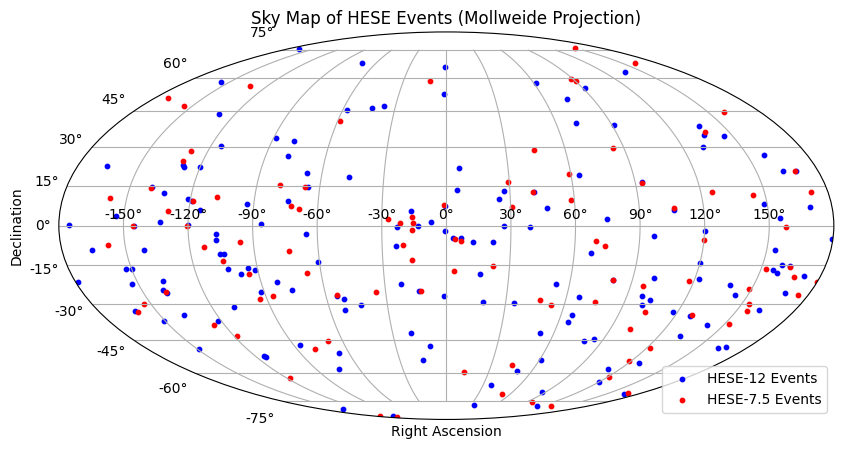

In [28]:
plt.figure(figsize=(10, 10))

plt.subplot(projection='mollweide')
plt.grid(True)

# plt.scatter(np.radians(plot_RA), np.radians(plot_Dec), c=grid.flatten(), cmap='GnBu', s=1, norm='log')
plt.scatter(HESE_12_RA, HESE_12_Dec, c='blue', s=10, label='HESE-12 Events')
plt.scatter(np.radians(HESE_75_RA), np.radians(HESE_75_Dec), c='red', s=10, label='HESE-7.5 Events')
plt.legend(loc='lower right')
plt.title('Sky Map of HESE Events (Mollweide Projection)')
plt.xlabel('Right Ascension')
plt.ylabel('Declination')
plt.show()

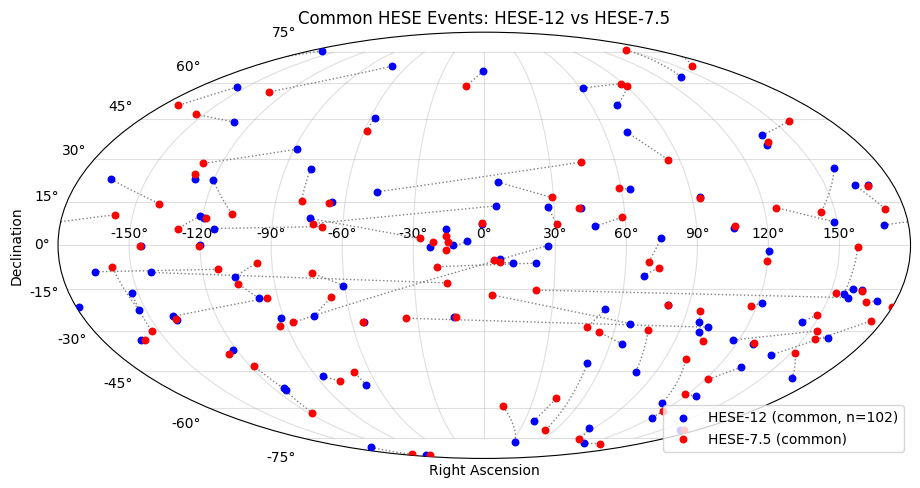

In [30]:
# Find common events by ID
common_ids, idx12, idx75 = np.intersect1d(HESE_12_ID, HESE_75_ID, return_indices=True)

# Coordinates for common events
ra12 = HESE_12_RA[idx12]                      # already in radians, in [-pi, pi]
dec12 = HESE_12_Dec[idx12]                    # radians
ra75 = np.radians(HESE_75_RA[idx75])          # convert deg -> rad
dec75 = np.radians(HESE_75_Dec[idx75])        # convert deg -> rad

plt.figure(figsize=(11, 8))
ax = plt.subplot(projection="mollweide")
ax.grid(True, alpha=0.4)

# Plot common-event positions from both datasets
ax.scatter(ra12, dec12, s=22, c="blue", label=f"HESE-12 (common, n={len(common_ids)})", zorder=3)
ax.scatter(ra75, dec75, s=22, c="red", label="HESE-7.5 (common)", zorder=3)

# Dotted lines connecting matched events
for x1, y1, x2, y2 in zip(ra12, dec12, ra75, dec75):
    ax.plot([x1, x2], [y1, y2], linestyle=":", color="gray", linewidth=0.8, alpha=0.8, zorder=2)

ax.set_title("Common HESE Events: HESE-12 vs HESE-7.5")

# Remove previously drawn direct connector lines
for ln in list(ax.lines):
    ln.remove()

# Re-draw connectors with wrap handling at RA = ±pi
for x1, y1, x2, y2 in zip(ra12, dec12, ra75, dec75):
    dx = x2 - x1

    # bring x2 close to x1 in angular sense
    if dx > np.pi:
        x2_adj = x2 - 2 * np.pi
    elif dx < -np.pi:
        x2_adj = x2 + 2 * np.pi
    else:
        x2_adj = x2

    # If no boundary crossing after adjustment, draw normally
    if -np.pi <= x2_adj <= np.pi:
        ax.plot([x1, x2_adj], [y1, y2], linestyle=":", color="gray", linewidth=1.0, alpha=1.0, zorder=2)
    else:
        # Split at boundary so line wraps around back of Mollweide map
        boundary = np.pi if x2_adj > np.pi else -np.pi
        t = (boundary - x1) / (x2_adj - x1)
        yb = y1 + t * (y2 - y1)

        ax.plot([x1, boundary], [y1, yb], linestyle=":", color="gray", linewidth=1.0, alpha=1.0, zorder=2)

        other_side = -np.pi if boundary == np.pi else np.pi
        x2_wrap = x2_adj - 2 * np.pi if x2_adj > np.pi else x2_adj + 2 * np.pi
        ax.plot([other_side, x2_wrap], [yb, y2], linestyle=":", color="gray", linewidth=1.0, alpha=1.0, zorder=2)

ax.legend(loc="lower right")
ax.set_xlabel("Right Ascension")
ax.set_ylabel("Declination")
plt.show()